In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data=pd.read_csv('ferrero_rocher_sales_dataset.csv')
data

,Store,Country,SKU,Date,Channel,Promotion,Units Sold,Unit Price,Discount,Revenue,Margin %,Margin
0,Tesco,UAE,Ferrero Rocher T3,45911,Wholesale,Diwali Promo,153,120,0.15,15606.0,30,4681.80
1,Tesco,USA,Ferrero Rocher 32pc,45940,Wholesale,Diwali Promo,143,750,0.15,91162.5,34,30995.25
2,Carrefour,Canada,Ferrero Rocher 32pc,45733,Retail,Buy1Get1,37,750,0.50,13875.0,37,5133.75
3,Walmart,India,Ferrero Collection 15pc,45945,Wholesale,NaN,101,650,0.00,65650.0,40,26260.00
4,Tesco,UK,Ferrero Rocher 16pc,45814,Retail,NaN,166,350,0.00,58100.0,30,17430.00
...,...,...,...,...,...,...,...,...,...,...,...,...
19995,Asda,UK,Ferrero Rocher T3,45776,Online,Diwali Promo,124,120,0.15,12648.0,30,3794.40
19996,Amazon Fresh,USA,Ferrero Rocher 24pc,45703,Online,NewYear Sale,68,550,0.25,28050.0,40,11220.00
19997,Tesco,UAE,Ferrero Rocher 32pc,45689,Retail,Buy1Get1,80,750,0.50,30000.0,29,8700.00
19998,ShengSiong,Singapore,Ferrero Rocher T3,45876,Online,Valentine Promo,116,120,0.10,12528.0,29,3633.12


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Store       20000 non-null  object 
 1   Country     20000 non-null  object 
 2   SKU         20000 non-null  object 
 3   Date        20000 non-null  int64  
 4   Channel     20000 non-null  object 
 5   Promotion   16744 non-null  object 
 6   Units Sold  20000 non-null  int64  
 7   Unit Price  20000 non-null  int64  
 8   Discount    20000 non-null  float64
 9   Revenue     20000 non-null  float64
 10  Margin %    20000 non-null  int64  
 11  Margin      20000 non-null  float64
dtypes: float64(3), int64(4), object(5)
memory usage: 1.8+ MB


In [5]:
data.describe()

,Date,Units Sold,Unit Price,Discount,Revenue,Margin %,Margin
count,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000
mean,45840.655600,104.643700,482.118000,0.20017,40327.728800,32.499500,13110.891813
std,105.347269,55.082185,225.728137,0.15484,31514.929185,4.630418,10512.371348
min,45658.000000,10.000000,120.000000,0.00000,600.000000,25.000000,156.000000
25%,45749.000000,57.000000,350.000000,0.10000,13750.000000,28.000000,4378.800000
50%,45842.000000,105.000000,550.000000,0.15000,32480.000000,32.000000,10386.350000
75%,45931.000000,152.000000,650.000000,0.25000,60255.000000,37.000000,19599.975000
max,46022.000000,199.000000,750.000000,0.50000,149250.000000,40.000000,57622.500000


In [6]:
data.isnull().sum()

Store            0
Country          0
SKU              0
Date             0
Channel          0
Promotion     3256
Units Sold       0
Unit Price       0
Discount         0
Revenue          0
Margin %         0
Margin           0
dtype: int64

In [8]:
data.fillna(0,inplace=True)

In [9]:
data.isnull().sum()

Store         0
Country       0
SKU           0
Date          0
Channel       0
Promotion     0
Units Sold    0
Unit Price    0
Discount      0
Revenue       0
Margin %      0
Margin        0
dtype: int64

In [11]:
country_sales = data.groupby("Country")["Revenue"].sum()
print(country_sales)

Country
Australia    110372016.5
Canada       118933986.0
India        109500098.5
Singapore    117317361.5
UAE          113703258.5
UK           121795428.0
USA          114932427.0
Name: Revenue, dtype: float64


In [12]:
store_sales = data.groupby("Store")["Revenue"].sum()

In [13]:
sku_sales = data.groupby("SKU")["Revenue"].sum()

In [14]:
promo_sales = data.groupby("Promotion")["Revenue"].sum()

In [15]:
channel_sales = data.groupby("Channel")["Revenue"].sum()

In [17]:
country_sales.sort_values(ascending=False).head(10)

Country
UK           121795428.0
Canada       118933986.0
Singapore    117317361.5
USA          114932427.0
UAE          113703258.5
Australia    110372016.5
India        109500098.5
Name: Revenue, dtype: float64

In [18]:
pd.pivot_table(
    data,
    values="Revenue",
    index="Country",
    columns="Channel",
    aggfunc="sum"
)

Channel,Offline,Online,Retail,Wholesale
Country,,,,
Australia,NaN,34429087.0,37855416.5,38087513.0
Canada,NaN,39478340.0,40028608.5,39427037.5
India,NaN,38293025.0,31312561.5,39894512.0
Singapore,NaN,39254310.5,39117715.5,38945335.5
UAE,NaN,32982810.0,42070908.5,38649540.0
UK,NaN,56751875.5,32971252.0,32072300.5
USA,8037950.5,52483342.0,26881421.5,27529713.0


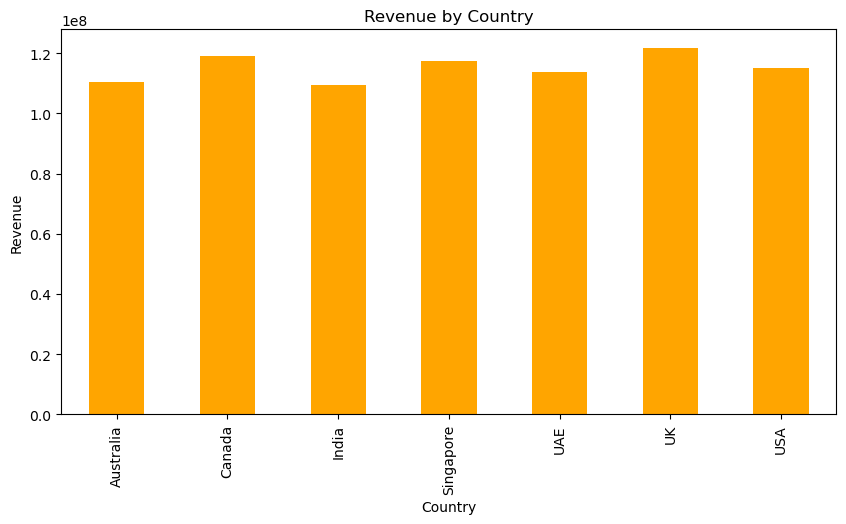

In [20]:
country_sales.plot(kind="bar", figsize=(10,5),color='orange')
plt.title("Revenue by Country")
plt.ylabel("Revenue")
plt.show()

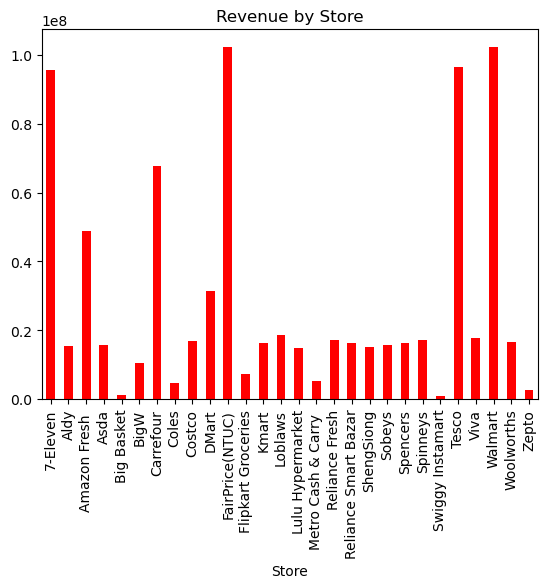

In [21]:
store_sales.plot(kind="bar",color='red')
plt.title("Revenue by Store")
plt.show()

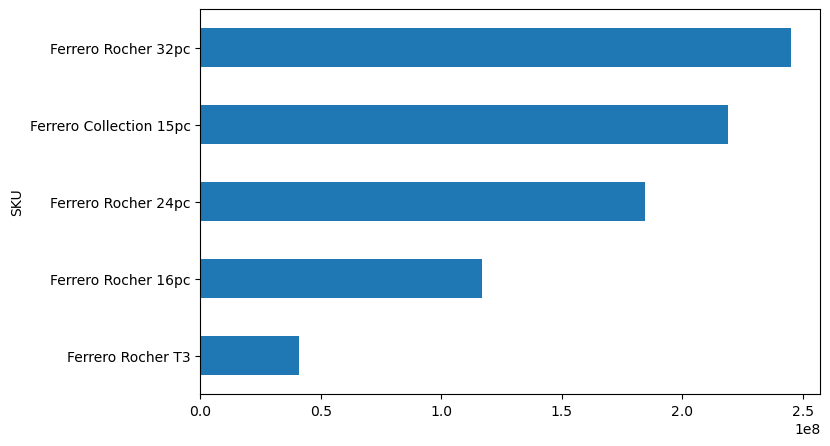

In [22]:
sku_sales.sort_values().plot(kind="barh", figsize=(8,5))
plt.show()

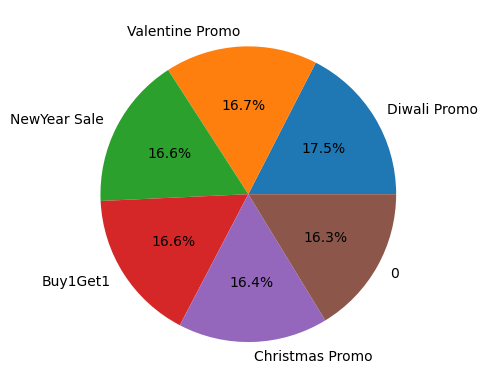

In [23]:
data["Promotion"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.ylabel("")
plt.show()

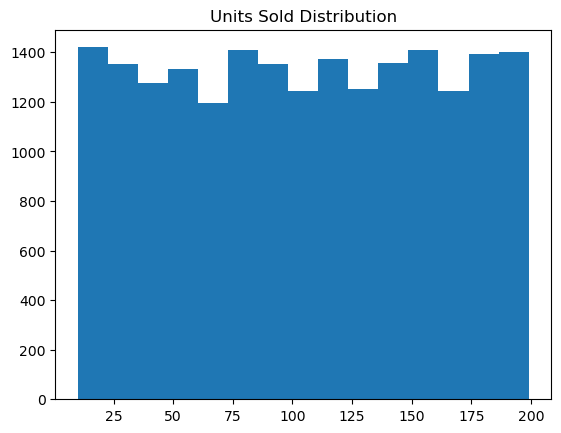

In [24]:
plt.hist(data["Units Sold"], bins=15)
plt.title("Units Sold Distribution")
plt.show()

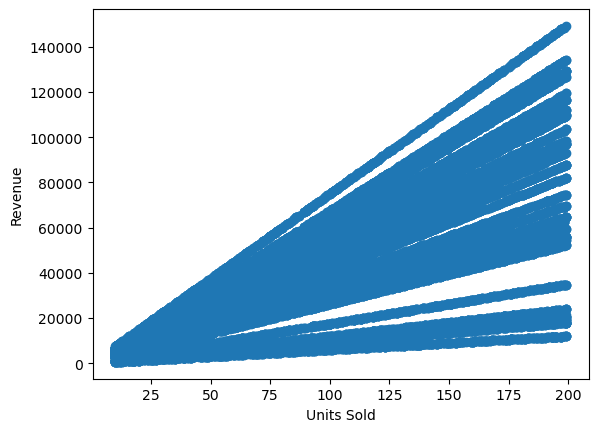

In [25]:
plt.scatter(data["Units Sold"], data["Revenue"])
plt.xlabel("Units Sold")
plt.ylabel("Revenue")
plt.show()

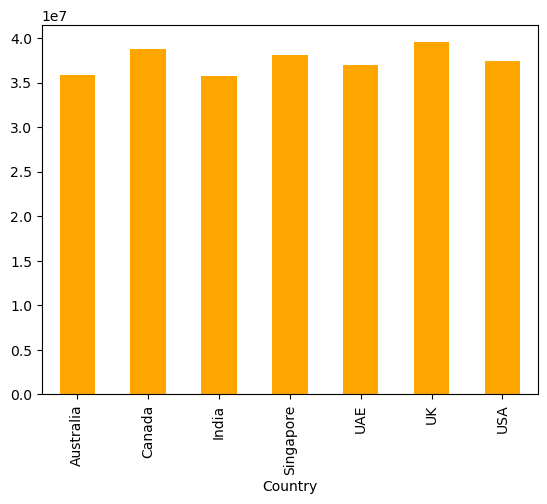

In [26]:
data.groupby("Country")["Margin"].sum().plot(kind="bar",color='orange')
plt.show()

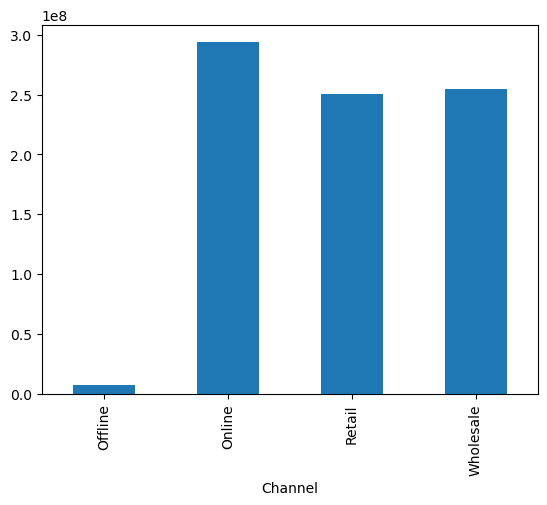

In [27]:
channel_sales.plot(kind="bar")
plt.show()

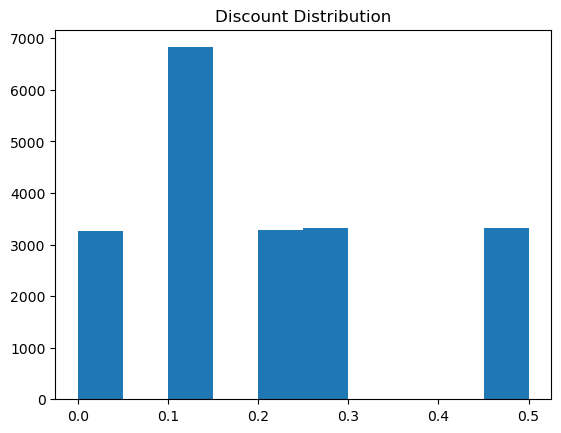

In [28]:
plt.hist(data["Discount"], bins=10)
plt.title("Discount Distribution")
plt.show()

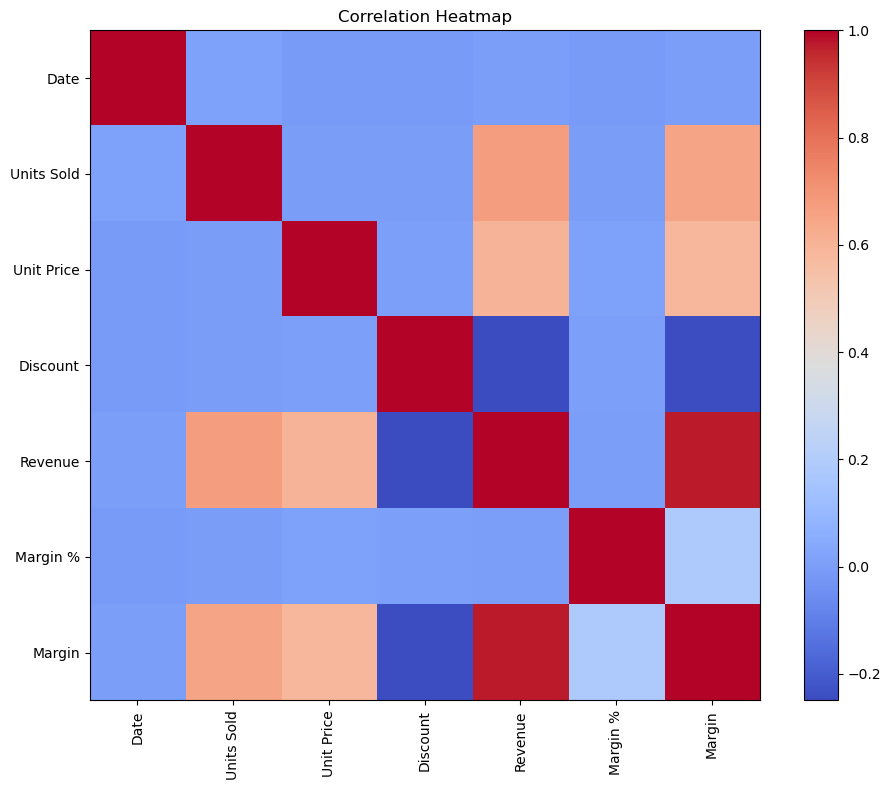

In [29]:
corr = data.select_dtypes(include='number').corr()
plt.figure(figsize=(10,8))
plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [30]:
data.to_csv("Ferrero_Clean_Data.csv", index=False)